In [56]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

In [57]:
DATASET_DIR = Path(r"C:\Users\anila\Downloads\archive (3)\Freshness Fish Dataset")

assert DATASET_DIR.exists(), f"Dataset path not found: {DATASET_DIR}"
print("Dataset directory:", DATASET_DIR)
print("Subfolders:", [p.name for p in DATASET_DIR.iterdir() if p.is_dir()])

Dataset directory: C:\Users\anila\Downloads\archive (3)\Freshness Fish Dataset
Subfolders: ['C1', 'C2', 'C3']


In [58]:
train_val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_val_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 1200 files belonging to 3 classes.
Using 960 files for training.
Found 1200 files belonging to 3 classes.
Using 240 files for validation.
Classes: ['C1', 'C2', 'C3']
Number of classes: 3


In [59]:
dataset_size = tf.data.experimental.cardinality(train_val_ds).numpy()
train_size = int(0.8 * dataset_size)

train_ds = train_val_ds.take(train_size)
val_ds = train_val_ds.skip(train_size)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 24
Validation batches: 6
Test batches: 8


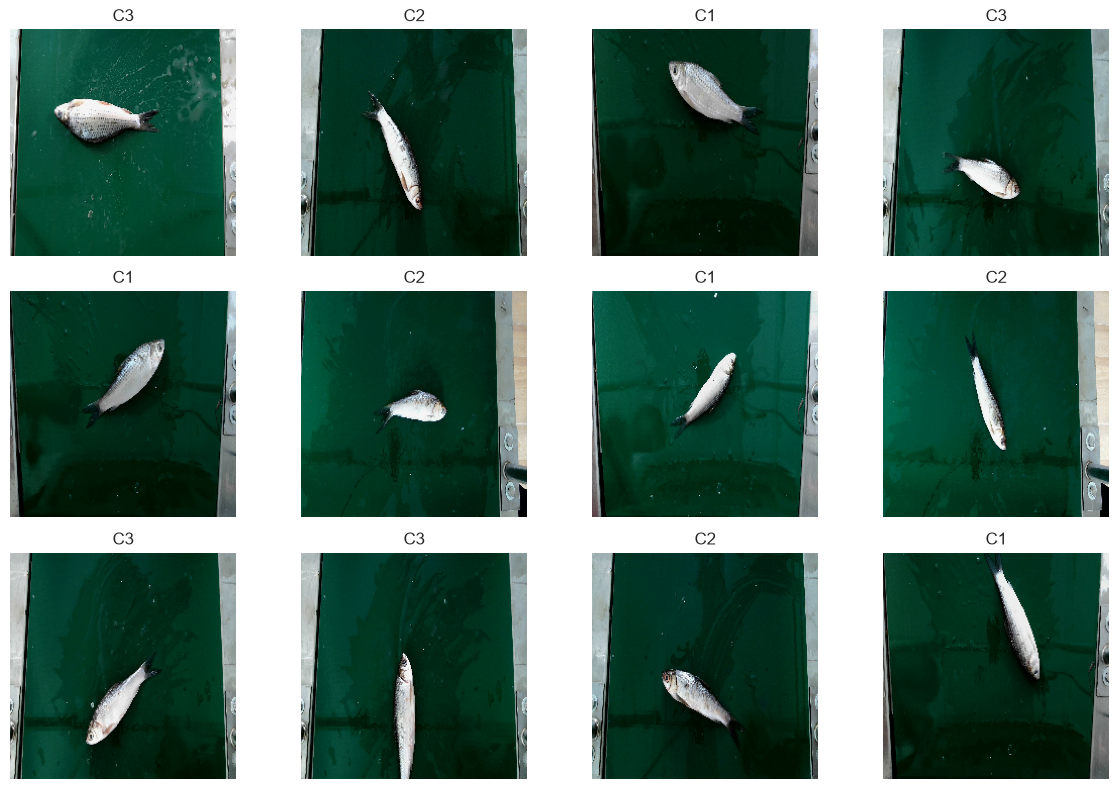

In [60]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0363883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.024131].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0319455].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0316471].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0542216].


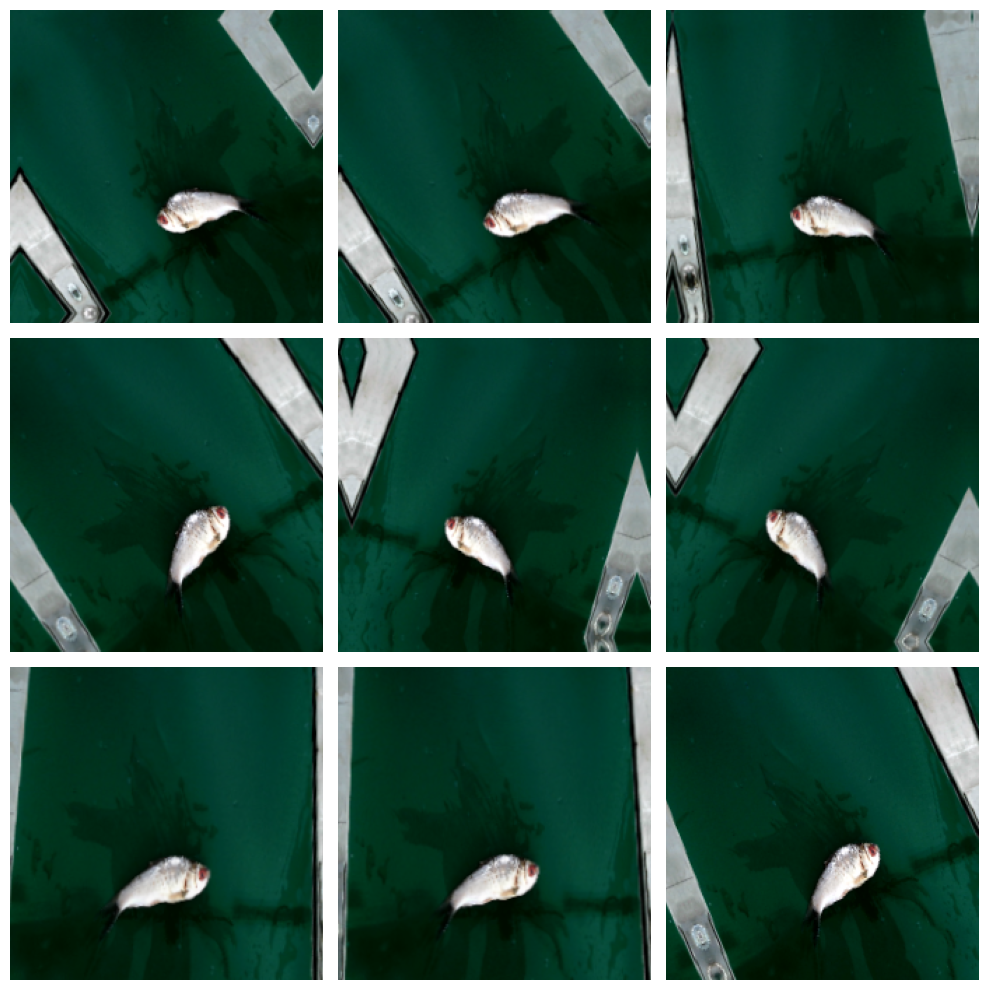

In [62]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        plt.imshow(augmented[0].numpy())
        plt.axis("off")
plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ], name="Custom_CNN")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

custom_cnn = build_custom_cnn(num_classes=num_classes)
custom_cnn.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 256)                 │      12,845,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,236,419 (50.49 MB)

 Trainable params: 13,235,459 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [64]:
def build_mobilenetv2_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_Transfer")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

mobilenet_model, mobilenet_base = build_mobilenetv2_model(num_classes=num_classes)
mobilenet_model.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ multiply_1 (Multiply)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_1 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_1 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [65]:
os.makedirs("saved_models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

callbacks_custom = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1),
    ModelCheckpoint("saved_models/custom_cnn_best.keras", monitor="val_accuracy", save_best_only=True)
]

callbacks_mobilenet = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1),
    ModelCheckpoint("saved_models/mobilenetv2_best.keras", monitor="val_accuracy", save_best_only=True)
]

In [66]:
history_custom = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_custom
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.7539 - loss: 5.2400 - val_accuracy: 0.3490 - val_loss: 2.1540 - learning_rate: 0.0010
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9284 - loss: 0.9233 - val_accuracy: 0.3333 - val_loss: 18.2702 - learning_rate: 0.0010
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9401 - loss: 0.6191
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9401 - loss: 0.5924 - val_accuracy: 0.3333 - val_loss: 49.9162 - learning_rate: 0.0010
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9766 - loss: 0.1721 - val_accuracy: 0.3333 - val_loss: 58.0542 - learning_rate: 3.0000e-04
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9749 - loss: 0.1373
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
24/24 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9740 - loss: 0.1215 - val_accurac

In [67]:
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_mobilenet
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 853ms/step - accuracy: 0.4974 - loss: 1.0427 - val_accuracy: 0.5417 - val_loss: 0.9375 - learning_rate: 0.0010
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 726ms/step - accuracy: 0.7214 - loss: 0.6627 - val_accuracy: 0.5677 - val_loss: 0.8500 - learning_rate: 0.0010
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 665ms/step - accuracy: 0.7930 - loss: 0.5066 - val_accuracy: 0.7552 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 661ms/step - accuracy: 0.8333 - loss: 0.4470 - val_accuracy: 0.7708 - val_loss: 0.6026 - learning_rate: 0.0010
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 667ms/step - accuracy: 0.8594 - loss: 0.3536 - val_accuracy: 0.8281 - val_loss: 0.4928 - learning_rate: 0.0010
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 637ms/step - accuracy: 0.8672 - loss: 0.3325 - val_accuracy: 0.7656 - val_loss: 0.5762 - learning_rate: 0.0010
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.8720 - loss: 0.3

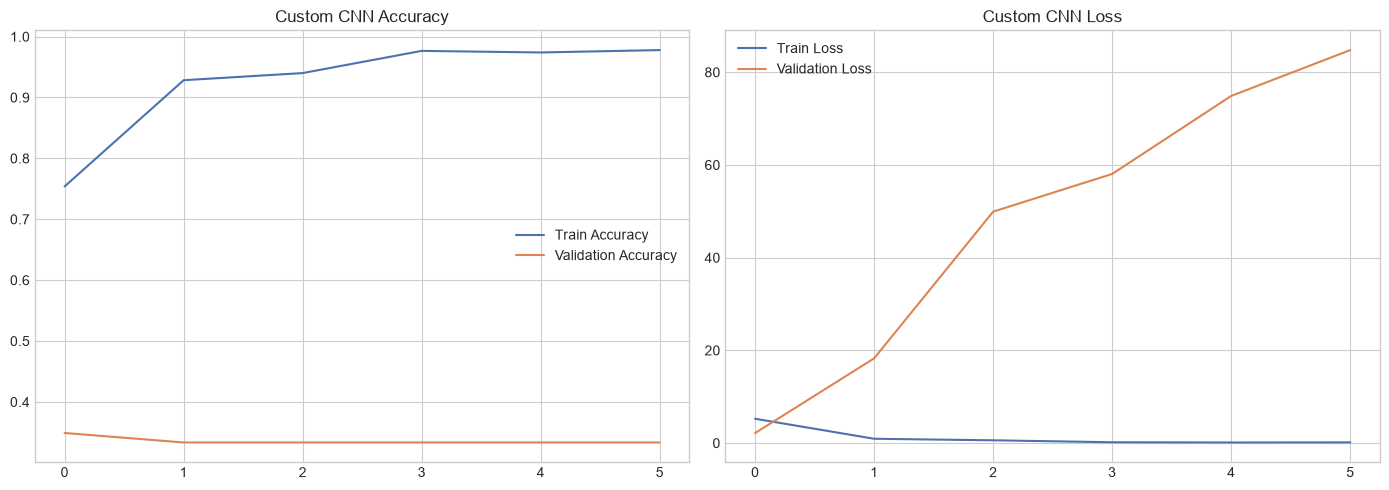

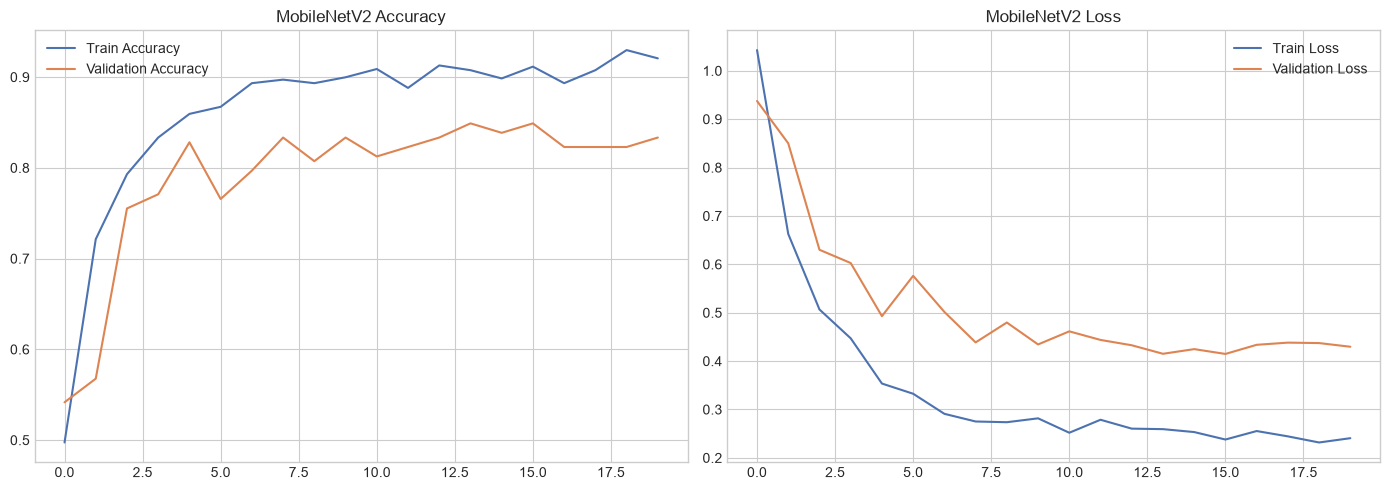

In [68]:
def plot_history(history, title_prefix, save_path):
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist["accuracy"], label="Train Accuracy")
    axes[0].plot(hist["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{title_prefix} Accuracy")
    axes[0].legend()

    axes[1].plot(hist["loss"], label="Train Loss")
    axes[1].plot(hist["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{title_prefix} Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_history(history_custom, "Custom CNN", "figures/custom_cnn_curves.png")
plot_history(history_mobilenet, "MobileNetV2", "figures/mobilenetv2_curves.png")

In [71]:
def get_true_and_pred(model, dataset):
    y_true, y_pred, y_prob = [], [], []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

In [70]:
y_true_cnn, y_pred_cnn, y_prob_cnn = get_true_and_pred(custom_cnn, test_ds)
y_true_mob, y_pred_mob, y_prob_mob = get_true_and_pred(mobilenet_model, test_ds)

cnn_test_loss, cnn_test_acc = custom_cnn.evaluate(test_ds, verbose=0)
mob_test_loss, mob_test_acc = mobilenet_model.evaluate(test_ds, verbose=0)

print("Custom CNN Test Accuracy:", cnn_test_acc)
print("MobileNetV2 Test Accuracy:", mob_test_acc)

Custom CNN Test Accuracy: 0.800000011920929
MobileNetV2 Test Accuracy: 0.8500000238418579


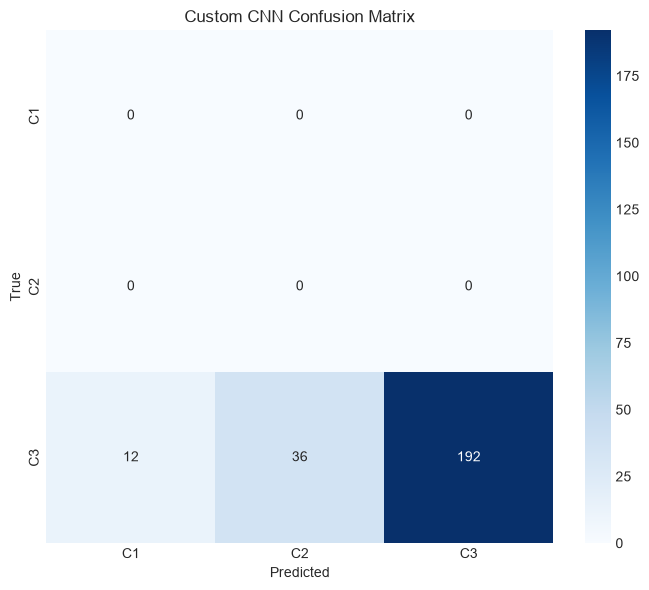

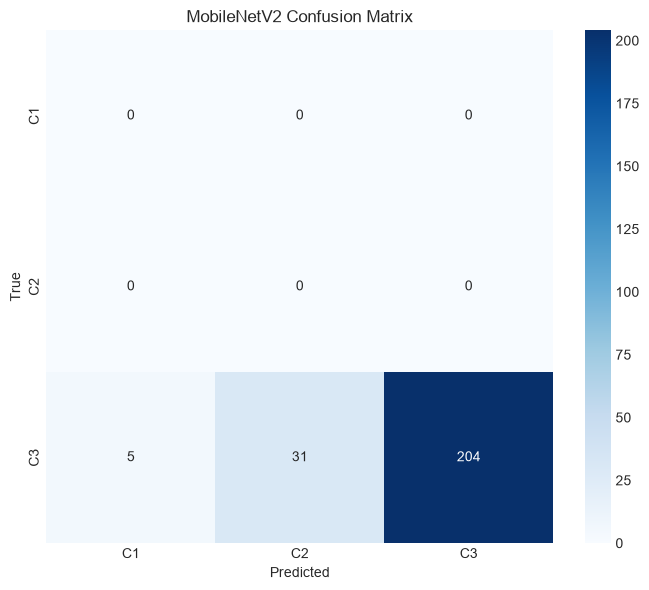

In [72]:
def plot_conf_matrix(y_true, y_pred, class_names, title, save_path):
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_conf_matrix(y_true_cnn, y_pred_cnn, class_names,
                 "Custom CNN Confusion Matrix",
                 "figures/custom_cnn_confusion_matrix.png")

plot_conf_matrix(y_true_mob, y_pred_mob, class_names,
                 "MobileNetV2 Confusion Matrix",
                 "figures/mobilenetv2_confusion_matrix.png")

In [73]:
labels = np.arange(len(class_names))

report_cnn = classification_report(
    y_true_cnn,
    y_pred_cnn,
    labels=labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_mob = classification_report(
    y_true_mob,
    y_pred_mob,
    labels=labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_cnn_df = pd.DataFrame(report_cnn).transpose()
report_mob_df = pd.DataFrame(report_mob).transpose()

display(report_cnn_df)
display(report_mob_df)

report_cnn_df.to_csv("figures/custom_cnn_classification_report.csv")
report_mob_df.to_csv("figures/mobilenetv2_classification_report.csv")

,precision,recall,f1-score,support
C1,0.000000,0.000000,0.000000,0.0
C2,0.000000,0.000000,0.000000,0.0
C3,1.000000,0.800000,0.888889,240.0
accuracy,0.800000,0.800000,0.800000,0.8
macro avg,0.333333,0.266667,0.296296,240.0
weighted avg,1.000000,0.800000,0.888889,240.0


,precision,recall,f1-score,support
C1,0.000000,0.000000,0.000000,0.00
C2,0.000000,0.000000,0.000000,0.00
C3,1.000000,0.850000,0.918919,240.00
accuracy,0.850000,0.850000,0.850000,0.85
macro avg,0.333333,0.283333,0.306306,240.00
weighted avg,1.000000,0.850000,0.918919,240.00


C:\Users\anila\tfenv\Lib\site-packages\sklearn\metrics\_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


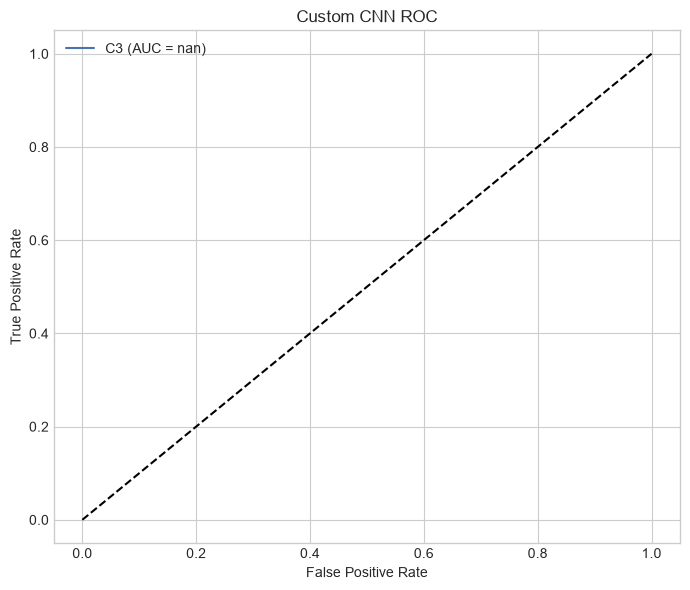

C:\Users\anila\tfenv\Lib\site-packages\sklearn\metrics\_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


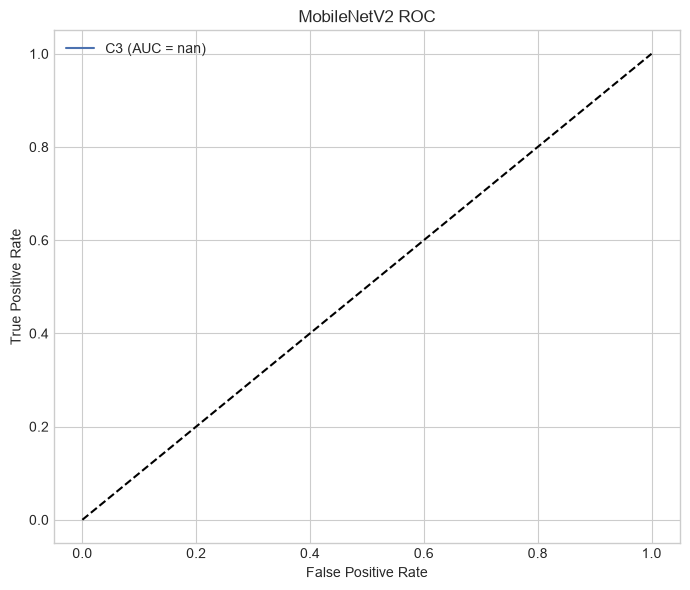

In [74]:
def plot_roc(y_true, y_prob, class_names, title, save_path):
    plt.figure(figsize=(7, 6))
    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))

    for i, class_name in enumerate(class_names):
        if np.sum(y_true_bin[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_roc(y_true_cnn, y_prob_cnn, class_names, "Custom CNN ROC", "figures/custom_cnn_roc.png")
plot_roc(y_true_mob, y_prob_mob, class_names, "MobileNetV2 ROC", "figures/mobilenetv2_roc.png")

In [75]:
comparison_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Test Accuracy": [cnn_test_acc, mob_test_acc],
    "Test Loss": [cnn_test_loss, mob_test_loss],
    "Weighted Precision": [
        report_cnn["weighted avg"]["precision"],
        report_mob["weighted avg"]["precision"]
    ],
    "Weighted Recall": [
        report_cnn["weighted avg"]["recall"],
        report_mob["weighted avg"]["recall"]
    ],
    "Weighted F1-score": [
        report_cnn["weighted avg"]["f1-score"],
        report_mob["weighted avg"]["f1-score"]
    ]
})

display(comparison_df)
comparison_df.to_csv("figures/model_comparison.csv", index=False)

,Model,Test Accuracy,Test Loss,Weighted Precision,Weighted Recall,Weighted F1-score
0,Custom CNN,0.80,0.525751,1.0,0.80,0.888889
1,MobileNetV2,0.85,0.491251,1.0,0.85,0.918919


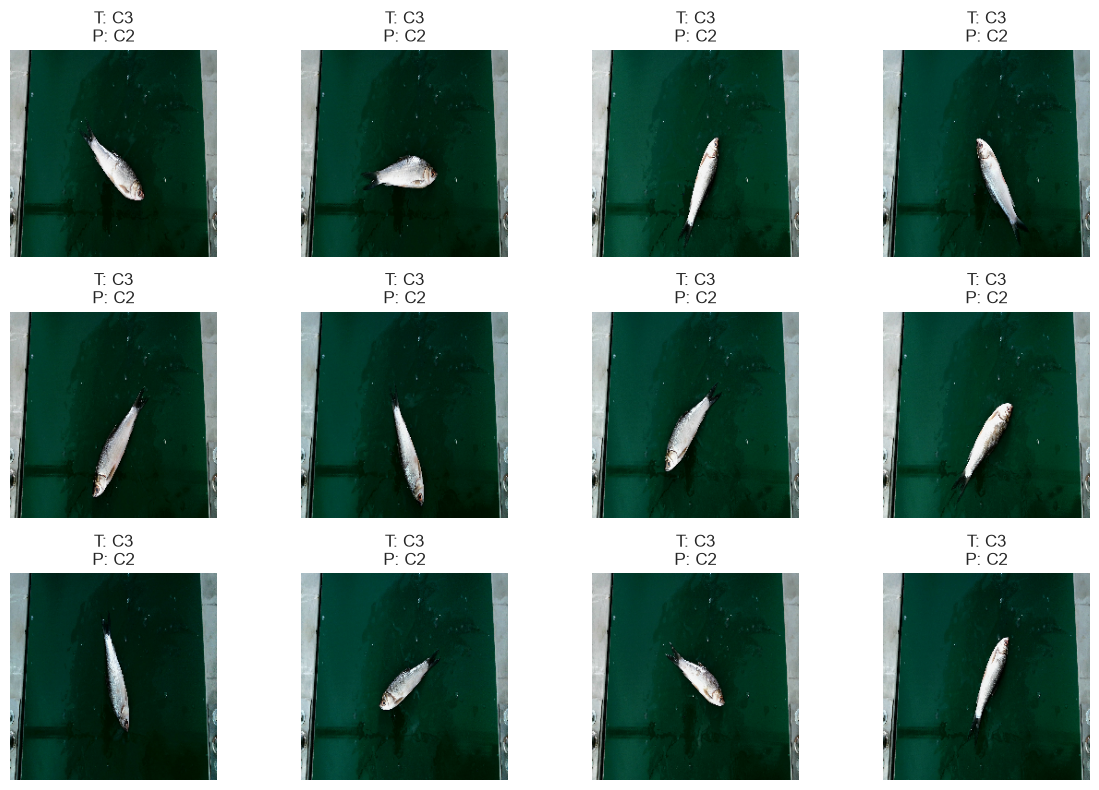

In [76]:
def get_misclassified_images(model, dataset, class_names, max_images=12):
    images_list, true_list, pred_list = [], [], []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)
        preds = np.argmax(probs, axis=1)

        for i in range(len(y_batch)):
            if y_batch[i].numpy() != preds[i]:
                images_list.append(x_batch[i].numpy())
                true_list.append(class_names[y_batch[i].numpy()])
                pred_list.append(class_names[preds[i]])

            if len(images_list) >= max_images:
                return images_list, true_list, pred_list

    return images_list, true_list, pred_list

mis_imgs, mis_true, mis_pred = get_misclassified_images(mobilenet_model, test_ds, class_names)

plt.figure(figsize=(12, 8))
for i in range(len(mis_imgs)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(mis_imgs[i])
    plt.title(f"T: {mis_true[i]}\nP: {mis_pred[i]}")
    plt.axis("off")
plt.tight_layout()
plt.savefig("figures/misclassified_images.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
def get_last_conv_layer_name(model):
    if model.name == "MobileNetV2_Transfer":
        return "Conv_1"
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    if model.name == "MobileNetV2_Transfer":
        base_model = model.get_layer("mobilenetv2_1.00_224")
        last_conv_layer = base_model.get_layer(last_conv_layer_name)
        grad_model = tf.keras.models.Model(
            [model.inputs],
            [last_conv_layer.output, model.output]
        )
    else:
        grad_model = tf.keras.models.Model(
            [model.inputs],
            [model.get_layer(last_conv_layer_name).output, model.output]
        )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.math.reduce_max(heatmap)
    if max_val != 0:
        heatmap = heatmap / max_val

    return heatmap.numpy()

def save_gradcam(model, dataset, class_names, save_path="figures/gradcam_result.png"):
    for images, labels in dataset.take(1):
        img = images[0].numpy()
        img_array = tf.expand_dims(images[0], axis=0)

        last_conv_layer_name = get_last_conv_layer_name(model)
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

        heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        original = np.uint8(img * 255) if img.max() <= 1.0 else np.uint8(img)
        overlay = cv2.addWeighted(cv2.cvtColor(original, cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(original)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        axes[1].imshow(heatmap)
        axes[1].set_title("Grad-CAM Heatmap")
        axes[1].axis("off")

        axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[2].set_title("Overlay")
        axes[2].axis("off")

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        break

save_gradcam(mobilenet_model, test_ds, class_names)

ValueError: Output with path `0` is not connected to `inputs`

In [78]:
custom_cnn.save("saved_models/custom_cnn_final.keras")
mobilenet_model.save("saved_models/mobilenetv2_final.keras")

with open("saved_models/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Models and labels saved successfully.")

Models and labels saved successfully.
